# Radiation Patterns: Far-Field Body Waves in a Homogeneous Whole Space

> **Colab note:** This notebook is designed to run on **Google Colab**. The first code cell installs dependencies. [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/UW-geophysics-edu/ess-412-512-intro2seismology/blob/main/notebooks/Radiation_Pattern_Synthetic.ipynb)

**Context:** Follow-up lab to the moment tensor module.

**Goal:** Build intuition for how a moment tensor maps to **P** and **S** far-field radiation patterns and how those patterns depend on receiver direction.

**Prediction-first rule:** For each experiment, write a short prediction *before* running the cell.

---

## What we model

- Homogeneous, isotropic whole space
- Point source at the origin
- Far-field only (1/r dependence)
- Arbitrary moment tensor $\mathbf{M}$

Key references (course): ITS Ch. 9.3 (far-field expressions, nodal structure).

## Setup

We will:
1. Define a moment tensor $M_{ij}$ (symmetric 3×3).
2. Sample takeoff directions $\gamma$ over the sphere.
3. Compute:
   - **P radiation amplitude:** $A_P(\gamma) \propto \gamma^T M \gamma$
   - **S radiation vector:** $\mathbf{A}_S(\gamma) \propto (I - \gamma\gamma^T) M \gamma$
4. Visualize:
   - 3D "lobe" plots
   - Lower-hemisphere equal-area projection
   - Azimuthal cuts

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Use consistent figure sizing
plt.rcParams['figure.figsize'] = (7, 6)
plt.rcParams['axes.grid'] = True


## Helper functions

We define:
- Spherical grid (theta, phi)
- Direction cosines $\gamma$
- P and S amplitudes for an arbitrary moment tensor

**Note:** This is geometry-only scaling; we suppress constants like $1/(4\pi\rho\alpha^3 r)$.


In [22]:
def spherical_grid(n_theta=181, n_phi=361):
    theta = np.linspace(0, np.pi, n_theta)       # 0..pi
    phi = np.linspace(0, 2*np.pi, n_phi)         # 0..2pi
    TH, PH = np.meshgrid(theta, phi, indexing='ij')
    return TH, PH

def gamma_from_theta_phi(theta, phi):
    # gamma = [sinθ cosφ, sinθ sinφ, cosθ]
    gx = np.sin(theta)*np.cos(phi)
    gy = np.sin(theta)*np.sin(phi)
    gz = np.cos(theta)
    G = np.stack([gx, gy, gz], axis=-1)  # (..., 3)
    return G

def p_amplitude(M, G):
    # A_P = gamma^T M gamma
    # einsum: ...i,ij,...j -> ...
    return np.einsum('...i,ij,...j->...', G, M, G)

def s_vector(M, G):
    # A_S = (I - gg^T) M g
    Mg = np.einsum('ij,...j->...i', M, G)
    # projection: Mg - g (g·Mg)
    gdotMg = np.einsum('...i,...i->...', G, Mg)
    return Mg - G * gdotMg[..., None]

def s_amplitude(M, G):
    AS = s_vector(M, G)
    return np.linalg.norm(AS, axis=-1)

def normalize(M):
    # scale moment tensor for display stability
    s = np.max(np.abs(M))
    return M / s if s != 0 else M


## Choose a moment tensor

### Convention (xyz):
- x = East
- y = North
- z = Up

Start with a **simple double couple**.

**Prediction:** Before running, sketch where you expect P nodal planes to be.


In [23]:
# Example 1: a simple DC-like tensor (not tied to strike/dip/rake here)
M = np.array([[0, 1, 0],
              [1, 0, 0],
              [0, 0, 0]], dtype=float)

M = normalize(M)
M


array([[0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 0.]])

## Compute radiation fields on the sphere

In [24]:
TH, PH = spherical_grid(n_theta=181, n_phi=361)
G = gamma_from_theta_phi(TH, PH)

AP = p_amplitude(M, G)
AS = s_amplitude(M, G)

AP.min(), AP.max(), AS.min(), AS.max()


(np.float64(-1.0),
 np.float64(1.0000000000000002),
 np.float64(0.0),
 np.float64(1.0))

## Visualization 1: Lower-hemisphere polarity map (P)

We plot the **sign** of $A_P$ on the lower hemisphere (takeoff directions with $\gamma_z \le 0$).

**Interpretation prompt:**  
- Identify nodal lines (where $A_P = 0$).  
- How many quadrants do you see?  
- Which regions are compressional vs. dilatational?

(Recall: in the simplest convention, sign corresponds to first-motion polarity.)


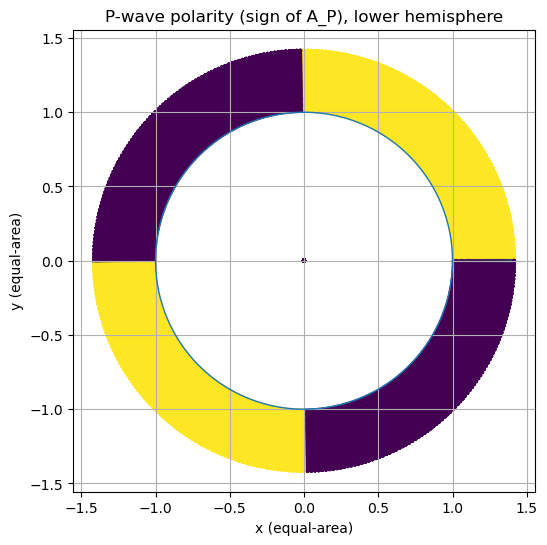

In [25]:
def lower_hemisphere_equal_area(G, A):
    # Lambert azimuthal equal-area projection for lower hemisphere
    # For lower hemisphere, use points with gz <= 0
    gx, gy, gz = G[...,0], G[...,1], G[...,2]
    mask = gz <= 0
    # colatitude for lower hemisphere: theta in [pi/2, pi]
    theta = np.arccos(np.clip(gz, -1, 1))
    # radius in equal-area projection: r = sqrt(2) * sin(theta/2)
    r = np.sqrt(2) * np.sin(theta/2)
    # projected coords
    x = r * (gx / np.sqrt(gx**2 + gy**2 + 1e-15))
    y = r * (gy / np.sqrt(gx**2 + gy**2 + 1e-15))
    return x[mask], y[mask], A[mask]

x, y, a = lower_hemisphere_equal_area(G, AP)

fig, ax = plt.subplots()
sc = ax.scatter(x, y, c=np.sign(a), s=4)
ax.set_aspect('equal', 'box')
ax.set_title("P-wave polarity (sign of A_P), lower hemisphere")
ax.set_xlabel("x (equal-area)")
ax.set_ylabel("y (equal-area)")
# Draw unit circle boundary
t = np.linspace(0, 2*np.pi, 400)
ax.plot(np.cos(t), np.sin(t), linewidth=1)
plt.show()


## Visualization 2: Radiation lobes (P and S)

We plot lobe magnitude by scaling the radius with $|A|$.

**Prompt:**  
- P: why are there nodal *planes*?  
- S: why do you expect nodal *points* (not planes)?


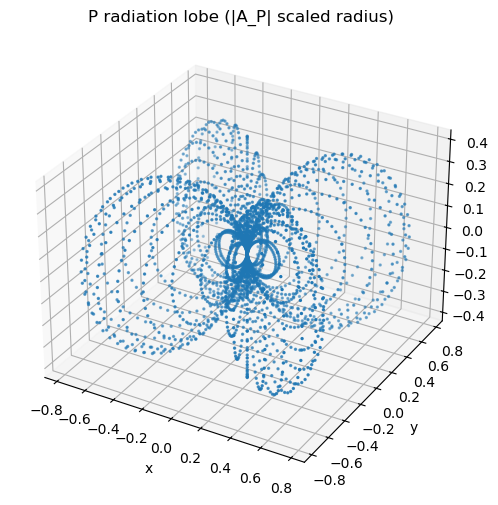

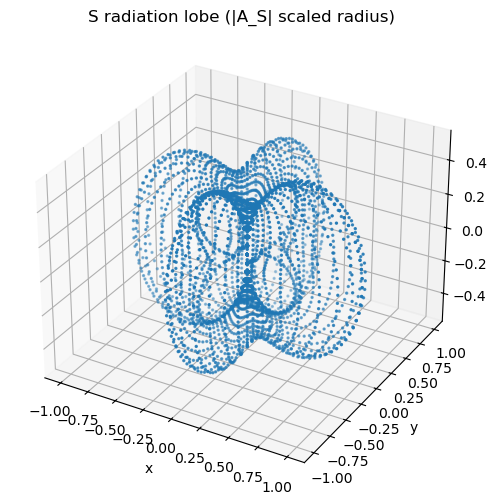

In [26]:
def lobe_xyz(G, A):
    # scale direction by |A| (normalized)
    An = np.abs(A)
    An = An / (An.max() + 1e-15)
    X = G[...,0] * An
    Y = G[...,1] * An
    Z = G[...,2] * An
    return X, Y, Z

# Downsample for plotting speed
step_t, step_p = 3, 6
Gd = G[::step_t, ::step_p, :]
APd = AP[::step_t, ::step_p]
ASd = AS[::step_t, ::step_p]

Xp, Yp, Zp = lobe_xyz(Gd, APd)
Xs, Ys, Zs = lobe_xyz(Gd, ASd)

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(Xp.ravel(), Yp.ravel(), Zp.ravel(), s=2)
ax.set_title("P radiation lobe (|A_P| scaled radius)")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
plt.show()

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(Xs.ravel(), Ys.ravel(), Zs.ravel(), s=2)
ax.set_title("S radiation lobe (|A_S| scaled radius)")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
plt.show()


## Visualization 3: Azimuthal cut (fixed takeoff angle)

Fix $\theta$ and plot $A_P(\phi)$.

**Prediction:** What periodicity do you expect for a double-couple-like source?


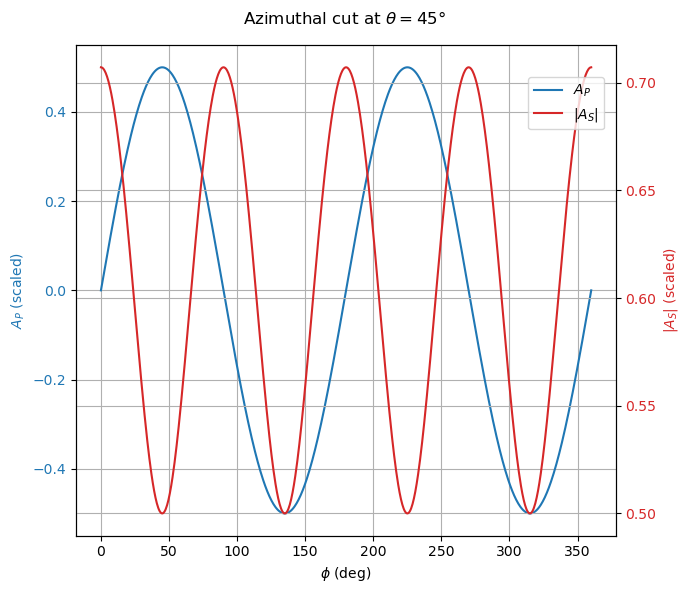

In [27]:
theta0_deg = 45
theta0 = np.deg2rad(theta0_deg)
phi = np.linspace(0, 2*np.pi, 720)
Gcut = gamma_from_theta_phi(theta0*np.ones_like(phi), phi)

Ap_cut = p_amplitude(M, Gcut)
As_cut = s_amplitude(M, Gcut)

fig, ax1 = plt.subplots()

color_p = "tab:blue"
ax1.plot(np.rad2deg(phi), Ap_cut, color=color_p, label="$A_P$")
ax1.set_xlabel("$\\phi$ (deg)")
ax1.set_ylabel("$A_P$ (scaled)", color=color_p)
ax1.tick_params(axis="y", labelcolor=color_p)

ax2 = ax1.twinx()
color_s = "tab:red"
ax2.plot(np.rad2deg(phi), As_cut, color=color_s, label="$|A_S|$")
ax2.set_ylabel("$|A_S|$ (scaled)", color=color_s)
ax2.tick_params(axis="y", labelcolor=color_s)

fig.suptitle(f"Azimuthal cut at $\\theta = {theta0_deg}°$")
fig.legend(loc="upper right", bbox_to_anchor=(0.88, 0.88))
fig.tight_layout()
plt.show()


# Experiments (Prediction-first)

## Experiment A — Add isotropic component

Set $M \leftarrow M + \lambda I$.

**Prediction prompts:**
- What happens to P nodal planes as $\lambda$ increases?
- Does S change? Why/why not?


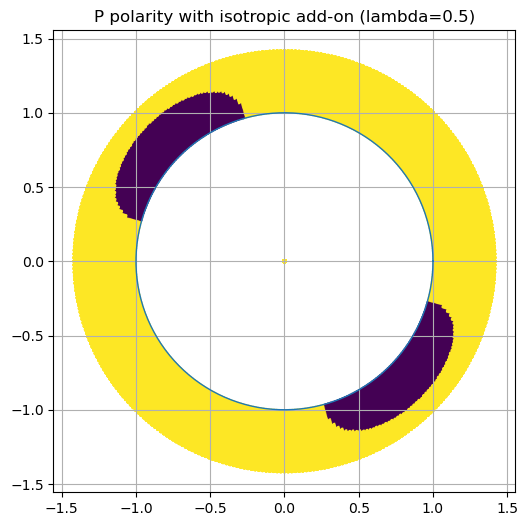

S amplitude range: 0.0 1.0


In [28]:
lam = 0.5
Mi = normalize(M + lam*np.eye(3))

APi = p_amplitude(Mi, G)
ASi = s_amplitude(Mi, G)

x, y, a = lower_hemisphere_equal_area(G, APi)
fig, ax = plt.subplots()
ax.scatter(x, y, c=np.sign(a), s=4)
ax.set_aspect('equal', 'box')
ax.set_title(f"P polarity with isotropic add-on (lambda={lam})")
t = np.linspace(0, 2*np.pi, 400)
ax.plot(np.cos(t), np.sin(t), linewidth=1)
plt.show()

print("S amplitude range:", ASi.min(), ASi.max())


## Experiment B — CLVD-like tensor

Use eigenvalues $[1, -1/2, -1/2]$.

**Prediction:** How many lobes for P? Where are nodal structures?


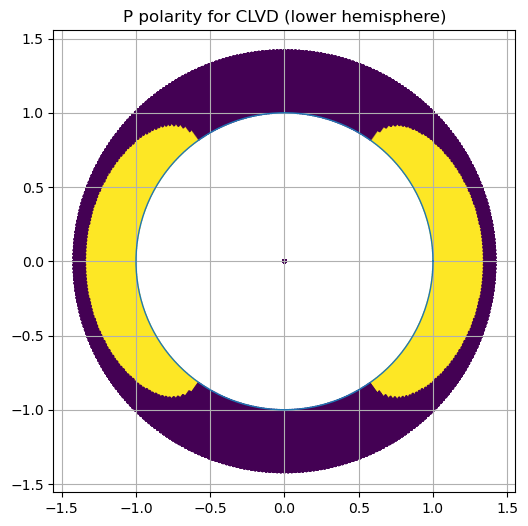

In [29]:
Mclvd = np.diag([1.0, -0.5, -0.5])
Mclvd = normalize(Mclvd)

APc = p_amplitude(Mclvd, G)
x, y, a = lower_hemisphere_equal_area(G, APc)

fig, ax = plt.subplots()
ax.scatter(x, y, c=np.sign(a), s=4)
ax.set_aspect('equal', 'box')
ax.set_title("P polarity for CLVD (lower hemisphere)")
t = np.linspace(0, 2*np.pi, 400)
ax.plot(np.cos(t), np.sin(t), linewidth=1)
plt.show()


## Experiment C — Random symmetric tensor

**Goal:** Practice reading patterns without “knowing the answer.”

**Prediction:** Before plotting, guess whether the map will resemble DC/CLVD/isotropic.


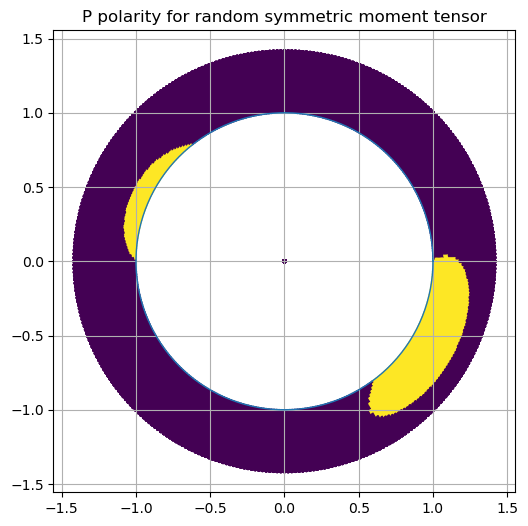

Moment tensor used: [[ 0.00249926 -0.60121746 -0.21738259]
 [-0.60121746 -0.92373987  0.35408784]
 [-0.21738259  0.35408784 -1.        ]]


In [30]:
rng = np.random.default_rng(7)
A = rng.normal(size=(3,3))
Mr = (A + A.T)/2
Mr = normalize(Mr)

APr = p_amplitude(Mr, G)
x, y, a = lower_hemisphere_equal_area(G, APr)

fig, ax = plt.subplots()
ax.scatter(x, y, c=np.sign(a), s=4)
ax.set_aspect('equal', 'box')
ax.set_title("P polarity for random symmetric moment tensor")
t = np.linspace(0, 2*np.pi, 400)
ax.plot(np.cos(t), np.sin(t), linewidth=1)
plt.show()

print("Moment tensor used:", Mr)


# Lab wrap-up questions

1. In your own words: what is $A_P(\gamma)$ measuring geometrically?
2. Compare DC vs CLVD: what symmetry difference is most diagnostic?
3. Why does adding isotropic moment remove nodal planes for P?
4. For S: why is polarization (direction) unavoidable for interpretation?

**Extension (optional):**  
Implement a simple “first-motion pick” simulator: sample random station directions, label sign(AP), and attempt to recover nodal planes.
